In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
n_per_class = 1000 # 각 클래스(원인결과) 당 샘플 수를 1000개로 설정
n_features = 5     # 센서 4개 + 공정 온도 특징 사용

# 클래스 0: 정상(센서 값 0 근처, 온도 50도 근처)
normal = np.random.normal(loc=[0,0,0,0,50], scale=[1,1,1,1,3], size=(n_per_class, n_features))

# 클래스 1: 센서불량(특정 센서1이 크게 튀는 데이터)
sensor_fault = np.random.normal(loc=[5,0,0,0,50], scale=[1.5,1,1,1,3], size=(n_per_class, n_features))

# 클래스 2: 윤활 문제(진동 센서 3,4가 상승)
lubrication_fault = np.random.normal(loc=[0,0,4,4,50], scale=[1,1,1.5,1.5,3], size=(n_per_class, n_features))

# 클래스 3: 냉각문제(온도가 많이 상승)
cooling_fault = np.random.normal(loc=[0,0,0,0,70], scale=[1,1,1,1,3], size=(n_per_class, n_features))

X = np.vstack([normal, sensor_fault, lubrication_fault, cooling_fault]) # 4개의 원인 데이터를 위아래로 붙임

y = np.hstack([
    np.zeros(n_per_class),             # 클래스 0: 정상
    np.ones(n_per_class),              # 클래스 1: 센서 불량
    np.full(n_per_class,2),            # 클래스 2: 윤활 문제
    np.full(n_per_class,3)             # 클래스 3: 냉각 문제
]).astype(int)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [6]:
# 4. 다중 분류 DNN 모델 정의

num_classes = 4
input_dim = n_features

model = models.Sequential()               # 순차적으로 레이어를 쌓는 Sequential 모델 생성
model.add(layers.Input(shape=(input_dim,))) # 첫 레이어로 입력 크기를 지정하는 input 레이어 생성
model.add(layers.Dense(16,activation='relu')) # 16개 뉴런의 레이어 추가, relu 활성화 함수 사용
model.add(layers.Dense(16,activation='relu')) # 또 16개 뉴런의 레이어 추가, relu 활성화 함수 사용 < -- 모델 성능 강화 위함
model.add(layers.Dense(num_classes,activation='softmax')) # 출력층은 클래스 개수만큼 뉴런을 두고 softmax로 각 원인에 대한 확률을 출력

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │              68 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 436 (1.70 KB)

 Trainable params: 436 (1.70 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# 모델 학습
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5112 - loss: 1.2129 - val_accuracy: 0.6589 - val_loss: 1.0715
Epoch 2/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7455 - loss: 0.9432 - val_accuracy: 0.7750 - val_loss: 0.8207
Epoch 3/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8580 - loss: 0.6972 - val_accuracy: 0.8839 - val_loss: 0.5913
Epoch 4/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9330 - loss: 0.4914 - val_accuracy: 0.9554 - val_loss: 0.4142
Epoch 5/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9696 - loss: 0.3429 - val_accuracy: 0.9696 - val_loss: 0.2915
Epoch 6/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9772 - loss: 0.2432 - val_accuracy: 0.9786 - val_loss: 0.2096
Epoch 7/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9808 - loss: 0.1774 - val_accuracy: 0.9839 - val_loss: 0.1563
Epoch 8/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9839 - loss: 0.1347 - val_accuracy: 0.9875 - val_loss

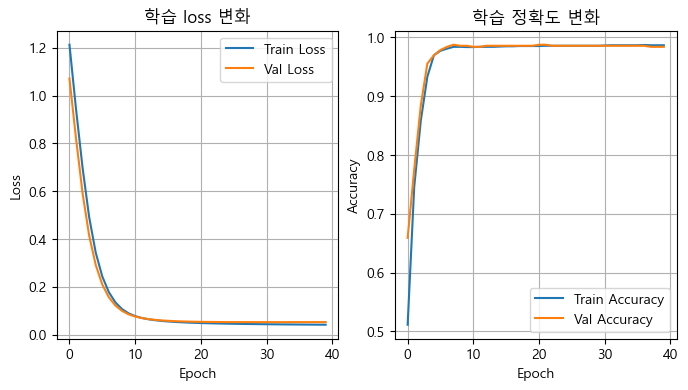

In [13]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('학습 loss 변화')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('학습 정확도 변화')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [14]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=1)    # 테스트 데이터에서 손실과 정확도 계산
print(f'테스트 정확도 : {test_acc:.3f}')                                  # 정확도 출력

y_pred_proba = model.predict(X_test_scaled)                               # 테스트 데이터의 샘플별 각 클래스 확률 계산
y_pred = np.argmax(y_pred_proba, axis=1)                                  # 가장 큰 확률을 가진 클래스를 최종 예측 레이블로 선택

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9775 - loss: 0.0647 
테스트 정확도 : 0.978
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [24]:
# 학습 모델 결과 저장
import joblib

model.save('./data/Model_save.keras')
print('Savemodel 형식 저장 완료')

model.save('./data/Fault_model.h5')
print('h5 포맷으로 저장 완료')

joblib.dump(scaler, './data/fault_scaler.h5')

Savemodel 형식 저장 완료
h5 포맷으로 저장 완료


['./data/fault_scaler.h5']

In [28]:
import joblib

loaded_model = tf.keras.models.load_model("./data/Model_save.keras")
loaded_model2 = model.save("./data/Fault_model.h5")

joblib.dump(scaler, './data/fault_scaler.h5')

C:\Users\human\anaconda3\envs\ai_new\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


['./data/fault_scaler.h5']

In [30]:
# 예측 테스트
pred_proba = loaded_model.predict(X_test_scaled)
pred_class = np.argmax(pred_proba, axis=1)[0]

print("예측결과")
print('입력데이터 : ', X_test)
print('예측된 클래스 : ', classification_report)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
예측결과
입력데이터 :  [[-1.25628604e+00 -4.59698142e-01 -2.40256840e-01 -8.93745282e-01
   6.65240347e+01]
 [ 4.22990498e+00  2.06135380e-01 -2.11167998e-03 -7.48071804e-01
   4.97772437e+01]
 [-4.31765489e-01 -1.66338671e+00  6.24400475e+00  3.55946121e+00
   4.68346951e+01]
 ...
 [ 6.62489266e+00 -6.05990046e-01 -9.42775240e-01 -3.07577390e-01
   4.70967430e+01]
 [-2.41430565e-01  1.46678256e+00  5.05557853e-01  4.36235705e-01
   4.64272505e+01]
 [-1.75475842e+00  6.46870465e-01  2.13805521e+00  7.12383345e-01
   6.76370152e+01]]
예측된 클래스 :  <function classification_report at 0x000002524F7A5760>


In [31]:
import joblib
import os

save_path = "./data/model_detection.h5"
model.save(save_path)

print(f"\n 모델이 성공적으로 저장되었습니다: {save_path}")


 모델이 성공적으로 저장되었습니다: ./data/model_detection.h5


In [32]:
import joblib

loaded_model = tf.keras.models.load_model(save_path)
print("저장된 모델을 성공적으로 불러왔습니다.")

저장된 모델을 성공적으로 불러왔습니다.


In [33]:
# 11. 예측 테스트
loaded_pred_proba = loaded_model.predict(X_test_scaled)
loaded_pred = np.argmax(loaded_pred_proba, axis=1)

print('저장된 모델 예측결과-상위 10개')
for i in range(10):
    print(f'샘플 {i+1} | 실제:{y_test[i]} --> 예측:{loaded_pred[i]}')

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
저장된 모델 예측결과-상위 10개
샘플 1 | 실제:3 --> 예측:3
샘플 2 | 실제:1 --> 예측:1
샘플 3 | 실제:2 --> 예측:2
샘플 4 | 실제:1 --> 예측:1
샘플 5 | 실제:3 --> 예측:3
샘플 6 | 실제:0 --> 예측:0
샘플 7 | 실제:3 --> 예측:3
샘플 8 | 실제:3 --> 예측:3
샘플 9 | 실제:0 --> 예측:0
샘플 10 | 실제:0 --> 예측:0


분류 리포트: 
               precision    recall  f1-score   support

           0       0.95      0.96      0.96       300
           1       0.98      0.97      0.97       300
           2       0.99      0.98      0.98       300
           3       1.00      1.00      1.00       300

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



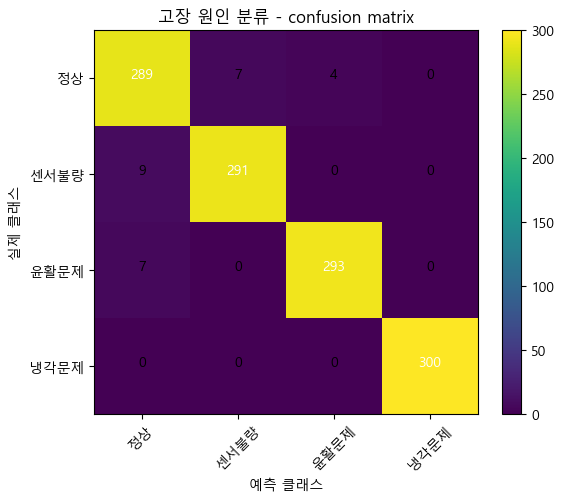

In [37]:
# 12. confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print('분류 리포트: \n', classification_report(y_test,y_pred))

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title('고장 원인 분류 - confusion matrix')
plt.colorbar()
tick_marks = np.arange(num_classes)
class_names = ['정상','센서불량','윤활문제','냉각문제']
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)


thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i, cm[i,j],
                 horizontalalignment = 'center',
                 color='white' if cm[i,j] > thresh else 'black')


plt.ylabel('실제 클래스')
plt.xlabel('예측 클래스')
plt.tight_layout()
plt.show()


=== 테스트 데이터 예측 진단 결과 ===

 [샘플 인덱스: 830 ]
센서/온도 값 = [ 0.66118547 -0.56882859  2.61338715  0.87957607 47.61447496]
실제 원인 = 윤활문제
예측 원인 =  윤활문제
예측 확률 벡터= [4.5656049e-01 1.2501348e-02 5.3069097e-01 2.4713160e-04]
가장 높은 예측 확률 =  0.531

 [샘플 인덱스: 783 ]
센서/온도 값 = [ 1.06561526 -1.16872091  0.28548694 -1.52901502 71.30907278]
실제 원인 = 냉각문제
예측 원인 =  냉각문제
예측 확률 벡터= [1.3423251e-04 2.9568606e-05 4.5909896e-06 9.9983156e-01]
가장 높은 예측 확률 =  1.000

 [샘플 인덱스: 926 ]
센서/온도 값 = [ 1.51795949e-01  7.63512567e-01  1.22472452e+00 -5.74359552e-03
  7.02133116e+01]
실제 원인 = 냉각문제
예측 원인 =  냉각문제
예측 확률 벡터= [2.9495746e-04 1.7799681e-05 2.2028677e-05 9.9966526e-01]
가장 높은 예측 확률 =  1.000

 [샘플 인덱스: 824 ]
센서/온도 값 = [ 0.28004534 -2.67456713 -1.75097557 -0.17749188 50.2473253 ]
실제 원인 = 정상
예측 원인 =  정상
예측 확률 벡터= [9.9831921e-01 1.5906264e-03 3.1364951e-05 5.8712896e-05]
가장 높은 예측 확률 =  0.998

 [샘플 인덱스: 327 ]
센서/온도 값 = [ 1.06179534  0.10780833 -0.10084135 -0.6001565  67.6191505 ]
실제 원인 = 냉각문제
예측 원인 =  냉각문제
예측 확률 벡터= [7.4280769e

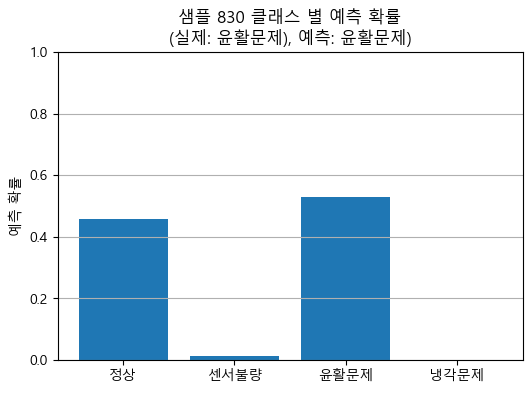

In [45]:
# 13. 테스트 데이터에 대한 개별 예측 진단


# 테스트 데이터 중 일부를 받아와서
# - 센서 값 / 온도
# - 실제 고장 원인
# - 모델이 예측한 고장 원인
# - 예측 확률(신뢰도)
# 출력해서 진단 결과 해석할 수 있도록 결과 제시

num_samples_to_show = 10

sample_indices = np.random.choice(len(X_test_scaled), size=num_samples_to_show, replace=False)

print('\n=== 테스트 데이터 예측 진단 결과 ===')
for idx in sample_indices:
    sensor_values = X_test[idx]    # 원본 스케일의 센서/온도 값을 ㅏㄱ져옴
    true_label = y_test[idx]        #실제 고장 원인 레이블(0~3)을 가져옴
    pred_label = y_pred[idx]        # 모델이 예측한 레이블(0~3)을 가져옴
    prob_vector = y_pred_proba[idx]  # 해당 샘플의 클래스별 예측 확률 벡터를 가져옴
    max_prob = np.max(prob_vector) # 가장 큰 확률값을 계산

    print('\n [샘플 인덱스:', idx, ']')
    print('센서/온도 값 =', sensor_values)
    print('실제 원인 =', class_names[true_label])
    print('예측 원인 = ', class_names[pred_label])
    print('예측 확률 벡터=', prob_vector)
    print('가장 높은 예측 확률 = ', f'{max_prob:.3f}')

sample_idx = sample_indices[0]
sample_prob = y_pred_proba[sample_idx]
sample_true = y_test[sample_idx]
sample_pred = y_pred[sample_idx]

plt.figure(figsize=(6,4))
plt.bar(range(num_classes), sample_prob)
plt.xticks(range(num_classes), class_names)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.ylabel('예측 확률')
plt.title(f'샘플 {sample_idx} 클래스 별 예측 확률\n'
         f'(실제: {class_names[sample_true]}), 예측: {class_names[sample_pred]})'
)
plt.grid(True, axis='y')
plt.show()